# **Komparasi Algoritma K-Means, DBSCAN, dan Fuzzy c-means dalam Pengelompokan Provinsi Berdasarkan Volatilitas Harga Pangan Strategis**

In [52]:
import polars as pl 
import pandas as pd
import plotly.express as px
from pathlib import Path
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score



In [67]:
project_dir = Path("/home/kali/supreme-adventure/data")
output_dir = Path("/home/kali/supreme-adventure/output")
geojson_path = Path("/home/kali/supreme-adventure/geojson")
print("Project exists :", project_dir.exists())
print("Output exists  :", output_dir.exists())

if project_dir.exists():
    print("\nIsi project dir:")
    for p in sorted(project_dir.iterdir()):
        print("-", p.name)

Project exists : True
Output exists  : True

Isi project dir:
- Bawang Merah.csv
- Bawang Putih Bonggol.csv
- Beras Medium.csv
- Beras Premium.csv
- Cabai Merah Keriting.csv
- Cabai Rawit Merah.csv
- Daging Ayam Ras.csv
- Daging Sapi Murni.csv
- Gula Konsumsi.csv
- Minyak Goreng Curah.csv
- Minyak Goreng Kemasan Sederhana.csv
- Telur Ayam Ras.csv
- Tepung Terigu (Curah).csv


In [3]:
KOMODITAS = {
    'bawang_merah': 'Bawang Merah.csv',
    'beras_medium': 'Beras Medium.csv',
    'beras_premium' : 'Beras Premium.csv',
    'minyak_curah': 'Minyak Goreng Curah.csv',
    'telur_ayam': 'Telur Ayam Ras.csv',
    'gula': 'Gula Konsumsi.csv',
    'Bawang_Putih_Bonggol' : 'Bawang Putih Bonggol.csv',
    'Cabai_Merah_Keriting' : 'Cabai Merah Keriting.csv',
    'Cabai_Rawit_Merah' : 'Cabai Rawit Merah.csv',
    'Daging_Ayam_Ras' : 'Daging Ayam Ras.csv',
    'Daging_Sapi_Murni': 'Daging Sapi Murni.csv',
    'Minyak_Goreng_Kemasan_Sederhana' : 'Minyak Goreng Kemasan Sederhana.csv',
    'Tepung_Terigu_Curah' : 'Tepung Terigu (Curah).csv'
}

In [4]:
data = {}

for key, filename in KOMODITAS.items():
    file_path = project_dir / filename
    data[key] = pl.read_csv(file_path)
    print(f"✓ {key}: {data[key].shape}")

✓ bawang_merah: (1004, 35)
✓ beras_medium: (1004, 35)
✓ beras_premium: (1004, 35)
✓ minyak_curah: (1004, 35)
✓ telur_ayam: (1004, 35)
✓ gula: (1004, 35)
✓ Bawang_Putih_Bonggol: (1004, 35)
✓ Cabai_Merah_Keriting: (1004, 35)
✓ Cabai_Rawit_Merah: (1004, 35)
✓ Daging_Ayam_Ras: (1004, 35)
✓ Daging_Sapi_Murni: (1004, 35)
✓ Minyak_Goreng_Kemasan_Sederhana: (1004, 35)
✓ Tepung_Terigu_Curah: (1004, 35)


In [5]:
print("Shape dari semua dataset: ")
i: int = 1;
for key,df in data.items(): 
    print(f"{i}. {key:20}: {df.shape}")
    i = i + 1

Shape dari semua dataset: 
1. bawang_merah        : (1004, 35)
2. beras_medium        : (1004, 35)
3. beras_premium       : (1004, 35)
4. minyak_curah        : (1004, 35)
5. telur_ayam          : (1004, 35)
6. gula                : (1004, 35)
7. Bawang_Putih_Bonggol: (1004, 35)
8. Cabai_Merah_Keriting: (1004, 35)
9. Cabai_Rawit_Merah   : (1004, 35)
10. Daging_Ayam_Ras     : (1004, 35)
11. Daging_Sapi_Murni   : (1004, 35)
12. Minyak_Goreng_Kemasan_Sederhana: (1004, 35)
13. Tepung_Terigu_Curah : (1004, 35)


In [6]:
print("Statistik Deskriptif dari semua dataset")
for key,df in data.items():
    print(f"{key:20}: {df.describe()}")

Statistik Deskriptif dari semua dataset
bawang_merah        : shape: (9, 36)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ Date      ┆ Aceh      ┆ Bali      ┆ … ┆ Sulawesi  ┆ Sumatera  ┆ Sumatera  ┆ Sumatera │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ Utara     ┆ Barat     ┆ Selatan   ┆ Utara    │
│ str       ┆ str       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 1004      ┆ 967.0     ┆ 968.0     ┆ … ┆ 970.0     ┆ 969.0     ┆ 966.0     ┆ 968.0    │
│ null_coun ┆ 0         ┆ 37.0      ┆ 36.0      ┆ … ┆ 34.0      ┆ 35.0      ┆ 38.0      ┆ 36.0     │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 

In [7]:
i: int = 1;
for key,df in data.items():
    print(f"{i}.{key:20}: {df.schema} \n")
    i = i + 1

1.bawang_merah        : Schema({'Date': String, 'Aceh': Float64, 'Bali': Float64, 'Banten': Float64, 'Bengkulu': Float64, 'DI Yogyakarta': Float64, 'DKI Jakarta': Float64, 'Gorontalo': Float64, 'Jambi': Float64, 'Jawa Barat': Float64, 'Jawa Tengah': Float64, 'Jawa Timur': Float64, 'Kalimantan Barat': Float64, 'Kalimantan Selatan': Float64, 'Kalimantan Tengah': Float64, 'Kalimantan Timur': Float64, 'Kalimantan Utara': Float64, 'Kepulauan Bangka Belitung': Float64, 'Kepulauan Riau': Float64, 'Lampung': Float64, 'Maluku Utara': Float64, 'Maluku': Float64, 'Nusa Tenggara Barat': Float64, 'Nusa Tenggara Timur': Float64, 'Papua Barat': Float64, 'Papua': Float64, 'Riau': Float64, 'Sulawesi Barat': Float64, 'Sulawesi Selatan': Float64, 'Sulawesi Tengah': Float64, 'Sulawesi Tenggara': Float64, 'Sulawesi Utara': Float64, 'Sumatera Barat': Float64, 'Sumatera Selatan': Float64, 'Sumatera Utara': Float64}) 

2.beras_medium        : Schema({'Date': String, 'Aceh': Float64, 'Bali': Float64, 'Banten':

In [8]:
i: int = 1
print(f"persentase missing")
for key,df in data.items():
    total_miss = df.select(pl.all().null_count().sum().item())
    total_data = df.height * df.width
    percent = (total_miss / total_data) * 100
    print(f"{i}.{key:20}: {percent}")
    i = i + 1

persentase missing
1.bawang_merah        : shape: (1, 35)
┌──────┬──────────┬──────────┬──────────┬───┬─────────────┬─────────────┬─────────────┬────────────┐
│ Date ┆ Aceh     ┆ Bali     ┆ Banten   ┆ … ┆ Sulawesi    ┆ Sumatera    ┆ Sumatera    ┆ Sumatera   │
│ ---  ┆ ---      ┆ ---      ┆ ---      ┆   ┆ Utara       ┆ Barat       ┆ Selatan     ┆ Utara      │
│ f64  ┆ f64      ┆ f64      ┆ f64      ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---        │
│      ┆          ┆          ┆          ┆   ┆ f64         ┆ f64         ┆ f64         ┆ f64        │
╞══════╪══════════╪══════════╪══════════╪═══╪═════════════╪═════════════╪═════════════╪════════════╡
│ 0.0  ┆ 0.105293 ┆ 0.102447 ┆ 0.105293 ┆ … ┆ 0.096756    ┆ 0.099602    ┆ 0.108139    ┆ 0.102447   │
└──────┴──────────┴──────────┴──────────┴───┴─────────────┴─────────────┴─────────────┴────────────┘
2.beras_medium        : shape: (1, 35)
┌──────┬──────────┬──────────┬──────────┬───┬─────────────┬─────────────┬─────────────┬────────

In [9]:
i: int = 0
for key,df in data.items():
    total_col: int = df.height * df.width
    missing = df.select(
        pl.sum_horizontal(pl.all().null_count())
    ).item()
    persentase: float = (missing / total_col) * 100
    print(f"{key:20s} : {missing} missing ({persentase:.2f}%)")
    i = i + 1

bawang_merah         : 1241 missing (3.53%)
beras_medium         : 1241 missing (3.53%)
beras_premium        : 1241 missing (3.53%)
minyak_curah         : 5437 missing (15.47%)
telur_ayam           : 1241 missing (3.53%)
gula                 : 1241 missing (3.53%)
Bawang_Putih_Bonggol : 1241 missing (3.53%)
Cabai_Merah_Keriting : 1244 missing (3.54%)
Cabai_Rawit_Merah    : 2035 missing (5.79%)
Daging_Ayam_Ras      : 1241 missing (3.53%)
Daging_Sapi_Murni    : 1245 missing (3.54%)
Minyak_Goreng_Kemasan_Sederhana : 1289 missing (3.67%)
Tepung_Terigu_Curah  : 1242 missing (3.53%)


# Analisis Missing
Terlihat rata missing value ada di angka 3% dan hanya minyak curah yg memiliki persentase 15%,dikarenakan yang akan di cluster adalah provinsi jadi selanjutnya akan di cek jumlah missing per provinsi untuk diputuskan apakah akan di drop

In [10]:
for key, df in data.items():
    print(f"\n📊 {key.upper()}")
    # =========================
    # 1. Missing per kolom
    # =========================
    missing_per_col = (
        df.select(pl.all().null_count())
        .transpose(include_header=True)
        .rename({"column": "provinsi", "column_0": "missing"})
        .filter(pl.col("missing") > 0)
        .sort("missing", descending=True)
    )

    if missing_per_col.height > 0:
        print("Provinsi dengan missing value:")

        top10 = missing_per_col.head(10)

        for row in top10.iter_rows(named=True):
            prov = row["provinsi"]
            count = row["missing"]
            pct = (count / df.height) * 100

            print(f"  {prov:25s} : {count:4d} missing ({pct:5.2f}%)")
    else:
        print("  ✓ No missing values")

    # =========================
    # 2. Missing per baris
    # =========================
    missing_per_row = df.select(
        pl.sum_horizontal(pl.all().is_null()).alias("missing")
    )

    rows_with_missing = missing_per_row.filter(pl.col("missing") > 0).height

    print(
        f"\nBaris dengan missing: {rows_with_missing} dari {df.height} "
        f"({(rows_with_missing/df.height)*100:.2f}%)"
    )


📊 BAWANG_MERAH
Provinsi dengan missing value:
  Kalimantan Timur          :   39 missing ( 3.88%)
  Kalimantan Utara          :   39 missing ( 3.88%)
  Kepulauan Riau            :   39 missing ( 3.88%)
  Papua Barat               :   39 missing ( 3.88%)
  Sulawesi Barat            :   39 missing ( 3.88%)
  Jambi                     :   38 missing ( 3.78%)
  Kepulauan Bangka Belitung :   38 missing ( 3.78%)
  Sumatera Selatan          :   38 missing ( 3.78%)
  Aceh                      :   37 missing ( 3.69%)
  Banten                    :   37 missing ( 3.69%)

Baris dengan missing: 46 dari 1004 (4.58%)

📊 BERAS_MEDIUM
Provinsi dengan missing value:
  Kalimantan Timur          :   39 missing ( 3.88%)
  Kalimantan Utara          :   39 missing ( 3.88%)
  Kepulauan Riau            :   39 missing ( 3.88%)
  Papua Barat               :   39 missing ( 3.88%)
  Sulawesi Barat            :   39 missing ( 3.88%)
  Jambi                     :   38 missing ( 3.78%)
  Kepulauan Bangka Belitung : 

# Analisis

Karena missing yang cukup signifikan pada dataset cabai rawit merah sebesar 80% dan minya curah sekitar 40%,maka kita harus drop untuk dataset tersebut.


## Note
Tersisa 11 Dataset

# Feature

Cari tau Tipe Missing pada 11 dataset tersebut,apakah MCAR,MAR,atau MNAR

# Drop 2 dataset cabai rawit merah dan minyak curah

In [11]:
del data["minyak_curah"]
del data["Cabai_Rawit_Merah"]

In [12]:
i: int = 1
for key,df in data.items():
    print(f"{i}.{key:20}: {df.height} kolom x {df.width} baris ")
    i = i + 1

1.bawang_merah        : 1004 kolom x 35 baris 
2.beras_medium        : 1004 kolom x 35 baris 
3.beras_premium       : 1004 kolom x 35 baris 
4.telur_ayam          : 1004 kolom x 35 baris 
5.gula                : 1004 kolom x 35 baris 
6.Bawang_Putih_Bonggol: 1004 kolom x 35 baris 
7.Cabai_Merah_Keriting: 1004 kolom x 35 baris 
8.Daging_Ayam_Ras     : 1004 kolom x 35 baris 
9.Daging_Sapi_Murni   : 1004 kolom x 35 baris 
10.Minyak_Goreng_Kemasan_Sederhana: 1004 kolom x 35 baris 
11.Tepung_Terigu_Curah : 1004 kolom x 35 baris 


In [13]:
missing_matrix = next(iter(data.values())).select("Date")

for key, df in data.items():
    miss = (
        df.drop("Date")
        .select(pl.any_horizontal(pl.all().is_null()).cast(pl.Int8))
        .to_series()
    )

    missing_matrix = missing_matrix.with_columns(
        miss.alias(key)
    )
    

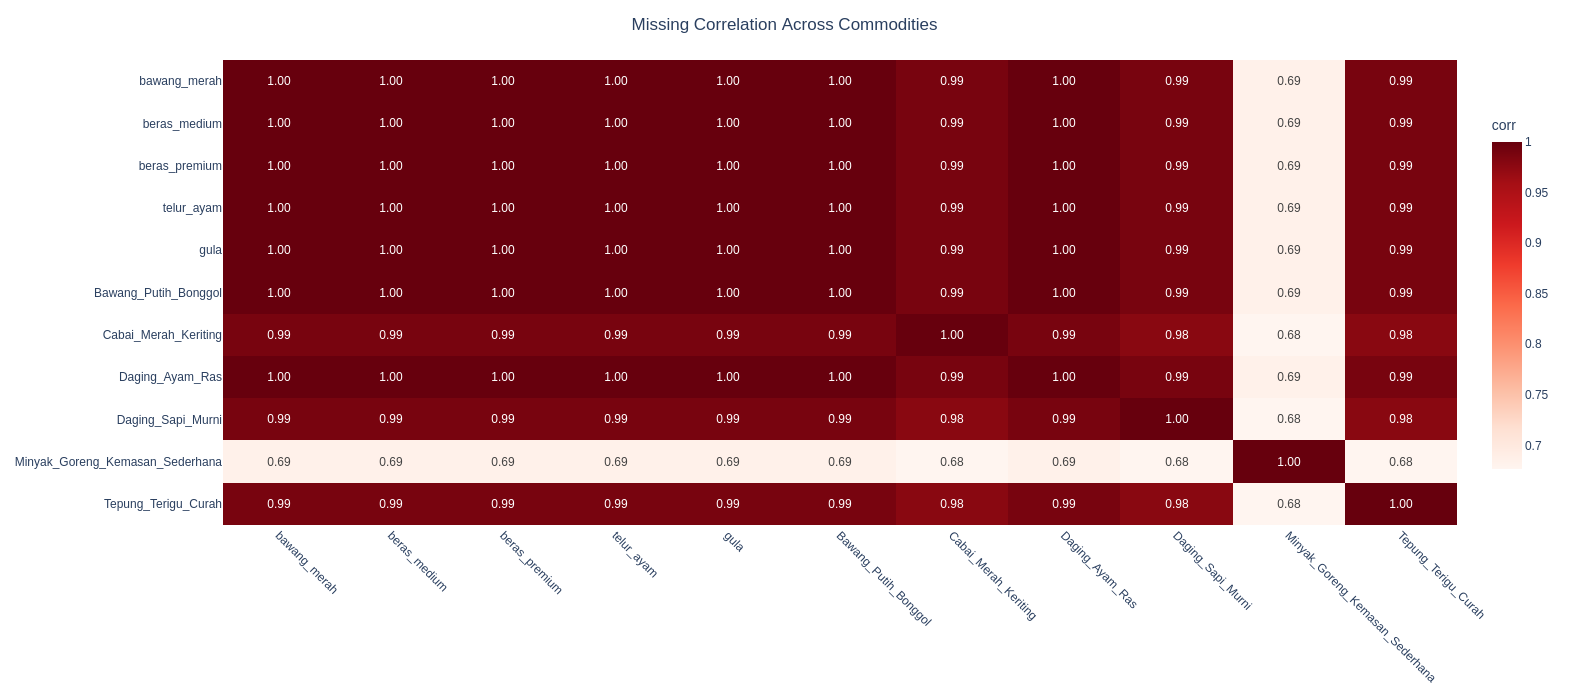

In [14]:
missing_corr = (
    missing_matrix
    .drop("Date")
    .to_pandas()
    .corr()
)
fig = px.imshow(
    missing_corr,
    text_auto=".2f",
    color_continuous_scale="Reds",
    aspect="auto"
)

fig.update_layout(
    title="Missing Correlation Across Commodities",
    title_x=0.5,
    width=900,
    height=700,
    font=dict(size=12),
    coloraxis_colorbar=dict(
        title="corr",
        len=0.8
    )
)

fig.update_xaxes(
    tickangle=45,
    side="bottom"
)

fig.update_yaxes(
    autorange="reversed"
)

fig.show()

In [15]:
print(missing_matrix.head(20))

shape: (20, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Date      ┆ bawang_me ┆ beras_med ┆ beras_pre ┆ … ┆ Daging_Ay ┆ Daging_Sa ┆ Minyak_Go ┆ Tepung_T │
│ ---       ┆ rah       ┆ ium       ┆ mium      ┆   ┆ am_Ras    ┆ pi_Murni  ┆ reng_Kema ┆ erigu_Cu │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ san_Seder ┆ rah      │
│           ┆ i8        ┆ i8        ┆ i8        ┆   ┆ i8        ┆ i8        ┆ han…      ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ ---       ┆ i8       │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ i8        ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2022-01-0 ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0        │
│ 1         ┆           ┆           ┆           ┆   ┆           ┆          

In [16]:
missing_matrix = missing_matrix.with_columns(
    pl.sum_horizontal(pl.exclude("Date")).alias("total")
)

missing_matrix.sort("total", descending=True).head(10)

Date,bawang_merah,beras_medium,beras_premium,telur_ayam,gula,Bawang_Putih_Bonggol,Cabai_Merah_Keriting,Daging_Ayam_Ras,Daging_Sapi_Murni,Minyak_Goreng_Kemasan_Sederhana,Tepung_Terigu_Curah,total
str,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""2022-03-22""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-05-03""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-10""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-11""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-12""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-13""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-14""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-15""",1,1,1,1,1,1,1,1,1,1,1,11
"""2022-06-16""",1,1,1,1,1,1,1,1,1,1,1,11


In [17]:
missing_matrix.select(pl.col("total").value_counts())

total
struct[2]
"{0,908}"
"{1,50}"
"{11,46}"


In [18]:
# ======================
# build missing matrix
# ======================
missing_matrix = next(iter(data.values())).select("Date")

for key, df in data.items():
    miss = (
        df.drop("Date")
        .select(pl.any_horizontal(pl.all().is_null()).cast(pl.Int8))
        .to_series()
    )

    missing_matrix = missing_matrix.with_columns(
        miss.alias(key)
    )

# ======================
# overlap calculation
# ======================
X = missing_matrix.drop("Date").to_numpy()

overlap = X.T @ X

overlap_df = pl.DataFrame(
    overlap,
    schema=missing_matrix.drop("Date").columns
)


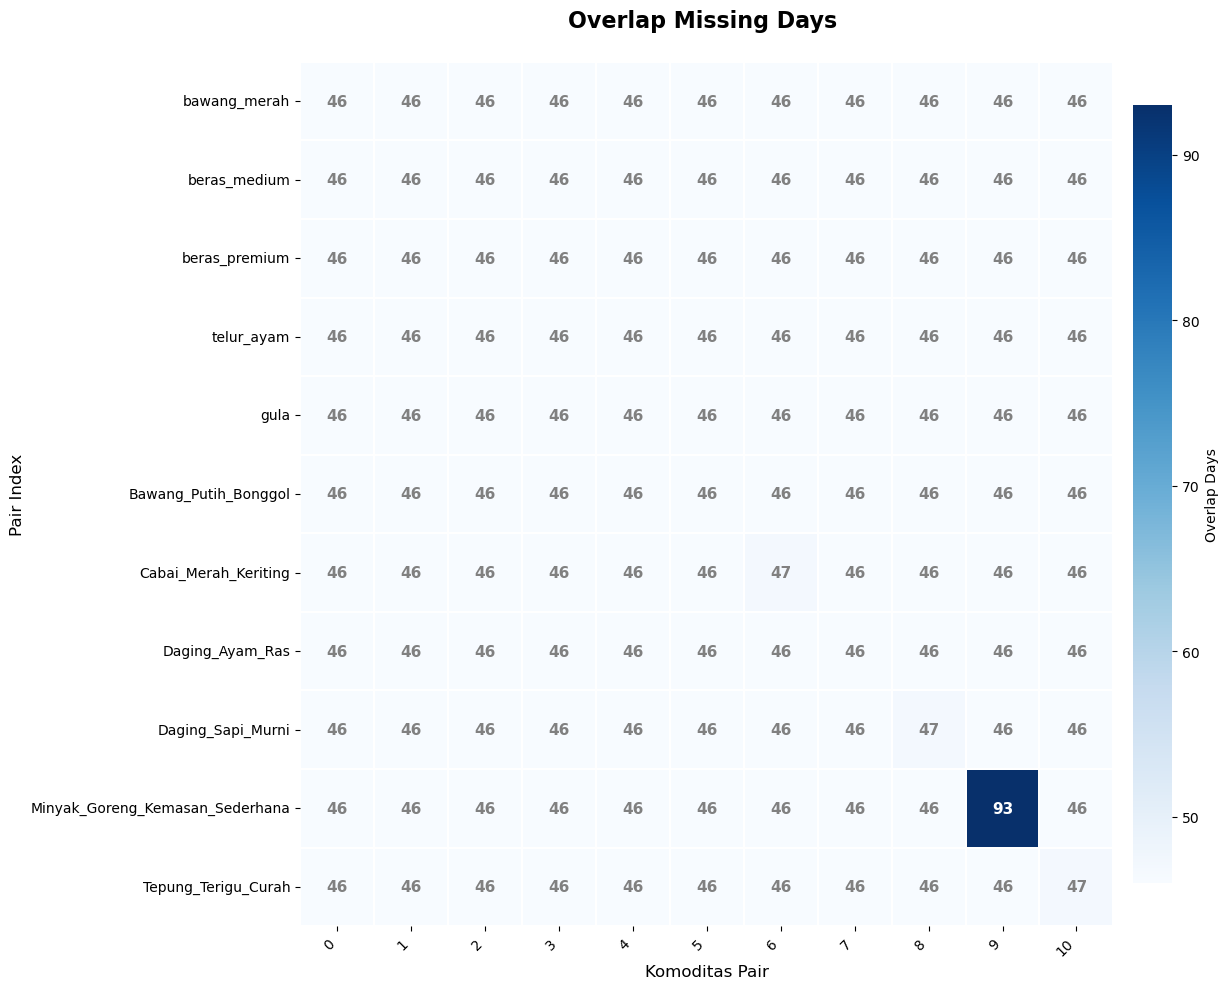

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

data_numeric = missing_matrix.to_pandas().select_dtypes(include='number')
overlap = data_numeric.T @ data_numeric.values

plt.figure(figsize=(13, 10))
sns.heatmap(
    overlap,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1.2,      # ← Grid lebih tebal
    linecolor='white',
    cbar_kws={
        'label': 'Overlap Days', 
        'shrink': 0.9,     # ← Colorbar lebih lebar
        'pad': 0.02
    },
    annot_kws={'size': 11, 'fontweight': 'bold', 'color': 'gray'}
)

# Highlight outlier
for text in plt.gca().texts:
    if float(text.get_text()) > 80:
        text.set_color('white')

plt.title("Overlap Missing Days ", 
          fontsize=16, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Komoditas Pair', fontsize=12)
plt.ylabel('Pair Index', fontsize=12)
plt.tight_layout()
plt.show()

# Analis
Pada visualisasi korelasi missing value antar komoditas dengan heatmap terlihat bahwa 10 dari 11 komoditas memiliki missing value yang identik yang dimana hal itu cukup untuk menarik kesimpulan bahwa tipe missing valuenya adalah MNAR atau dengan kata lain sistematis,sementara itu komoditas minyak goreng hanya memiliki korelasi sekitar $ 68\\% $ ,ini mengartikan bahwa missing value pada komoditas minyak goreng berbeda dengan 10 komoditas lainnya sekitar $ 32 \\%$  bersifat unik karena tidak muncul pada 10 komoditas lain,maka pilihannya adalah drop komoditas minyak goreng karena ada kemunkinan dimana kemunkinan besar komoditas minyak goreng adalah outlier

Visualisi Heatmap kedua bertujuan untuk menghitung jumlah hari yang sama ketika dua komoditas mengalami missing,hasil menunjukkan berbeda dengan komoditas lain yg mayoritas 46 - 47 hari minyak goreng malah missing sebanyak 93 hari artinya setengah missing di komoditas ini tidak muncul di komoditas lain, hal ini menegaskan bahwa komoditas minyak goreng adalah anomali atau outiers

# Keputusan
- [x] Drop dataset minyak_goreng sederhana
# Feature
- [x] Cari apakah ada rentang waktu sama,10 dataset tersisa memiliki rentang waktu missing yang sama
- [x] apakah interpolasi bisa dilakukan pada dataset tersisa,dan interpolasi apa(linear,atau polynomial)? 

In [20]:
del data["Minyak_Goreng_Kemasan_Sederhana"]

In [21]:
print("DATASET TERSISA")
i: int = 1
for key,df in data.items():
    print(f"{i}.{key:20}: {df.height} baris x {df.width} kolom")
    i = i + 1

DATASET TERSISA
1.bawang_merah        : 1004 baris x 35 kolom
2.beras_medium        : 1004 baris x 35 kolom
3.beras_premium       : 1004 baris x 35 kolom
4.telur_ayam          : 1004 baris x 35 kolom
5.gula                : 1004 baris x 35 kolom
6.Bawang_Putih_Bonggol: 1004 baris x 35 kolom
7.Cabai_Merah_Keriting: 1004 baris x 35 kolom
8.Daging_Ayam_Ras     : 1004 baris x 35 kolom
9.Daging_Sapi_Murni   : 1004 baris x 35 kolom
10.Tepung_Terigu_Curah : 1004 baris x 35 kolom


In [22]:
missing_matrix = next(iter(data.values())).select("Date")

for key, df in data.items():
    miss = (
        df.drop("Date")
        .select(pl.any_horizontal(pl.all().is_null()).cast(pl.Int8))
        .to_series()
    )

    missing_matrix = missing_matrix.with_columns(
        miss.alias(key)
    )

blackout_days = missing_matrix.filter(
    pl.all_horizontal(pl.exclude("Date") == 1)
)

print("Jumlah blackout day:", blackout_days.height)
print(f"{blackout_days.select("Date").sort("Date")}")

Jumlah blackout day: 46
shape: (46, 1)
┌────────────┐
│ Date       │
│ ---        │
│ str        │
╞════════════╡
│ 2022-03-22 │
│ 2022-05-03 │
│ 2022-06-10 │
│ 2022-06-11 │
│ 2022-06-12 │
│ …          │
│ 2024-03-11 │
│ 2024-04-10 │
│ 2024-04-11 │
│ 2024-06-17 │
│ 2024-06-18 │
└────────────┘


In [23]:
blackout = (
    blackout_days
    .with_columns(
        pl.col("Date").str.to_date()
    )
    .select("Date")
    .sort("Date")
    .with_columns(
        pl.col("Date").diff().dt.total_days().alias("gap")
    )
    .with_columns(
        (pl.col("gap").fill_null(1) != 1).cum_sum().alias("group")
    )
    .group_by("group")
    .agg([
        pl.col("Date").min().alias("start"),
        pl.col("Date").max().alias("end"),
        pl.len().alias("length")
    ])
    .drop("group")
)

print(blackout)

shape: (10, 3)
┌────────────┬────────────┬────────┐
│ start      ┆ end        ┆ length │
│ ---        ┆ ---        ┆ ---    │
│ date       ┆ date       ┆ u32    │
╞════════════╪════════════╪════════╡
│ 2023-09-20 ┆ 2023-09-20 ┆ 1      │
│ 2024-04-10 ┆ 2024-04-11 ┆ 2      │
│ 2022-08-03 ┆ 2022-08-03 ┆ 1      │
│ 2023-04-22 ┆ 2023-04-22 ┆ 1      │
│ 2022-06-10 ┆ 2022-07-14 ┆ 35     │
│ 2022-05-03 ┆ 2022-05-03 ┆ 1      │
│ 2022-03-22 ┆ 2022-03-22 ┆ 1      │
│ 2023-01-09 ┆ 2023-01-09 ┆ 1      │
│ 2024-03-11 ┆ 2024-03-11 ┆ 1      │
│ 2024-06-17 ┆ 2024-06-18 ┆ 2      │
└────────────┴────────────┴────────┘


# Analisis

Dari 46 missing days,terdapat rentang pendek(1 - 2 hari) dan rentang panjang(35 hari),strateginya adalah melakukan interpolasi pada rentang pendek lebih tepatnya Interpolasi Linear(mencari fungsi $y = f(x)$ yang melewati semua titik $x$).dan untuk rentang panjang dibiarkan null saja

# Feature

- [x] lakukan interpolasi linear pada rentang pendek(1 - 2 hari)

In [24]:
def interpolate_short(df, max_gap=2):
    # Pastikan data diurutkan
    df = df.sort("Date")
    
    exprs = [] # Tampung semua operasi kolom di list ini
    
    for c in df.columns:
        if c == "Date":
            continue

        # 1. Mask null
        is_null = pl.col(c).is_null()

        # 2. Hitung group id (tambahkan fill_null untuk baris pertama)
        grp = (is_null != is_null.shift()).fill_null(False).cum_sum()

        # 3. Panjang run null (Perbaiki urutan .sum() dan .over())
        run_len = (
            pl.when(is_null)
            .then(1)
            .otherwise(0)
            .sum()
            .over(grp)
        )

        # 4. Interpolasi kandidat (hitung semua)
        interp = pl.col(c).interpolate()

        # 5. Buat ekspresi: isi dengan interpolasi HANYA jika null dan gap <= max_gap
        expr = (
            pl.when(is_null & (run_len <= max_gap))
            .then(interp)
            .otherwise(pl.col(c))
            .alias(c) # Pastikan nama kolom tidak berubah
        )
        
        exprs.append(expr)

    # Eksekusi semuanya secara paralel dalam 1 panggilan (Sangat Cepat)
    out = df.with_columns(exprs)
    
    return out

# Cara panggilnya tetap sama:
cleaned = {k: interpolate_short(df, max_gap=2) for k, df in data.items()}

In [25]:
for key,df in cleaned.items():
    print(f"{key:20}: {df.shape}")

bawang_merah        : (1004, 35)
beras_medium        : (1004, 35)
beras_premium       : (1004, 35)
telur_ayam          : (1004, 35)
gula                : (1004, 35)
Bawang_Putih_Bonggol: (1004, 35)
Cabai_Merah_Keriting: (1004, 35)
Daging_Ayam_Ras     : (1004, 35)
Daging_Sapi_Murni   : (1004, 35)
Tepung_Terigu_Curah : (1004, 35)


In [36]:
final_data = {k: df.drop_nulls() for k, df in cleaned.items()}

# ==========================================
# validasi
# ==========================================
summary_data = []

for key, df in final_data.items():
    # Hitung apakah masih ada sehelai null pun yang tersisa
    total_nulls = df.select(pl.sum_horizontal(pl.all().null_count())).item()
    
    summary_data.append({
        "Dataset": key,
        "Total Baris Tersisa": df.height, # Melihat sisa baris setelah di-drop
        "Sisa Null": total_nulls,
        "Status": "✅ Bersih Sempurna" if total_nulls == 0 else "⚠️ Masih ada masalah"
    })

summary_df = pl.DataFrame(summary_data)

print("=== STATUS DATA SETELAH DROP NULLS ===")
print(summary_df)

=== STATUS DATA SETELAH DROP NULLS ===
shape: (10, 4)
┌──────────────────────┬─────────────────────┬───────────┬────────────────────┐
│ Dataset              ┆ Total Baris Tersisa ┆ Sisa Null ┆ Status             │
│ ---                  ┆ ---                 ┆ ---       ┆ ---                │
│ str                  ┆ i64                 ┆ i64       ┆ str                │
╞══════════════════════╪═════════════════════╪═══════════╪════════════════════╡
│ bawang_merah         ┆ 969                 ┆ 0         ┆ ✅ Bersih Sempurna │
│ beras_medium         ┆ 969                 ┆ 0         ┆ ✅ Bersih Sempurna │
│ beras_premium        ┆ 969                 ┆ 0         ┆ ✅ Bersih Sempurna │
│ telur_ayam           ┆ 969                 ┆ 0         ┆ ✅ Bersih Sempurna │
│ gula                 ┆ 969                 ┆ 0         ┆ ✅ Bersih Sempurna │
│ Bawang_Putih_Bonggol ┆ 969                 ┆ 0         ┆ ✅ Bersih Sempurna │
│ Cabai_Merah_Keriting ┆ 969                 ┆ 0         ┆ ✅ Bersih Semp

# Feature Engineering


# Feature
- [x] gabung dataset dalam wide format
- [x] analisis feature statistik apa yang paling bagus
- [x] standarisasi setelah feature engeneering  

In [37]:
all_features_list = []

# ==========================================
# 1. EKSTRAKSI & PEMBENTUKAN WIDE FORMAT
# ==========================================
for komoditas, df in final_data.items():
    prov_features = []
    prov_columns = [c for c in df.columns if c != "Date"]
    
    for prov in prov_columns:
        s = df.get_column(prov).drop_nulls()
        
        # Hitung semua kandidat fitur (termasuk yang dilarang untuk diaudit)
        mean_val = s.mean()
        std_val = s.std()
        cv = std_val / mean_val if mean_val != 0 else 0
        skew = s.skew()
        kurt = s.kurtosis()
        
        autocorr = (
            pl.DataFrame({"asli": s, "lag": s.shift(1)})
            .drop_nulls().select(pl.corr("asli", "lag")).item()
        )
        
        trend = (s[-1] - s[0]) / s[0] if s[0] != 0 else 0
        
        # Tambahkan prefix nama komoditas agar kolom tidak bentrok saat digabung
        prov_features.append({
            "Provinsi": prov,
            f"{komoditas}_Mean": mean_val,
            f"{komoditas}_CV": cv,
            f"{komoditas}_Skewness": skew,
            f"{komoditas}_Kurtosis": kurt,
            f"{komoditas}_Lag1": autocorr,
            f"{komoditas}_Trend": trend
        })
        
    # Ubah list dictionary menjadi Polars DataFrame
    df_komoditas_features = pl.DataFrame(prov_features)
    all_features_list.append(df_komoditas_features)

# GABUNGKAN SEMUA KE WIDE FORMAT (Inner Join berdasarkan Provinsi)
df_wide = all_features_list[0]
for i in range(1, len(all_features_list)):
    df_wide = df_wide.join(all_features_list[i], on="Provinsi", how="inner")


In [38]:
import polars as pl
import pandas as pd

# ==========================================
# 1. BUAT DATA STACKED (LONG FORMAT) UNTUK AUDIT GLOBAL
# ==========================================
stacked_features = []

for komoditas, df in final_data.items():
    prov_columns = [c for c in df.columns if c != "Date"]
    
    for prov in prov_columns:
        s = df.get_column(prov).drop_nulls()
        
        # Ekstraksi 4 Fitur 'The Dream Team'
        mean_val = s.mean()
        std_val = s.std()
        cv = std_val / mean_val if mean_val != 0 else 0
        kurt = s.kurtosis()
        
        autocorr = (
            pl.DataFrame({"asli": s, "lag": s.shift(1)})
            .drop_nulls().select(pl.corr("asli", "lag")).item()
        )
        
        trend = (s[-1] - s[0]) / s[0] if s[0] != 0 else 0
        
        stacked_features.append({
            "Provinsi": prov,
            "Komoditas": komoditas,
            "CV": cv,
            "Kurtosis": kurt,
            "Lag1": autocorr,
            "Trend": trend
        })

# Jadikan Polars DataFrame (340 Baris x 6 Kolom)
df_global_audit = pl.DataFrame(stacked_features)

print(f"=== 1. SHAPE DATA GLOBAL ===")
print(f"Total Sampel: {df_global_audit.height} (Harusnya 34 Provinsi x 10 Komoditas)")
print(df_global_audit.head(3))

# ==========================================
# 2. BUKTI 1: MATRIKS KORELASI GLOBAL (UNIVERSAL INDEPENDENCE)
# ==========================================
print("\n=== BUKTI 1: MATRIKS KORELASI GLOBAL 10 KOMODITAS ===")
print("Tujuan: Membuktikan bahwa The Dream Team valid untuk SEMUA komoditas.")

df_global_numeric = df_global_audit.select(["CV", "Kurtosis", "Lag1", "Trend"]).to_pandas()
global_corr_matrix = df_global_numeric.corr().round(3)
print(global_corr_matrix)

# ==========================================
# 3. BUKTI 2: DAYA PEMBEDA GLOBAL
# ==========================================
print("\n=== BUKTI 2: DAYA PEMBEDA KESELURUHAN ===")

stats = []
for col in ["CV", "Kurtosis", "Lag1", "Trend"]:
    s = df_global_audit.get_column(col)
    mean_val = s.mean()
    std_val = s.std()
    cv_feature = abs(std_val / mean_val) if mean_val != 0 else 0
    
    stats.append({
        "Fitur": col,
        "Min": s.min(),
        "Max": s.max(),
        "Rata-rata": round(mean_val, 3),
        "Variasi Global (CV)": round(cv_feature, 2)
    })

df_global_stats = pl.DataFrame(stats)
print(df_global_stats)

=== 1. SHAPE DATA GLOBAL ===
Total Sampel: 340 (Harusnya 34 Provinsi x 10 Komoditas)
shape: (3, 6)
┌──────────┬──────────────┬──────────┬──────────┬──────────┬───────────┐
│ Provinsi ┆ Komoditas    ┆ CV       ┆ Kurtosis ┆ Lag1     ┆ Trend     │
│ ---      ┆ ---          ┆ ---      ┆ ---      ┆ ---      ┆ ---       │
│ str      ┆ str          ┆ f64      ┆ f64      ┆ f64      ┆ f64       │
╞══════════╪══════════════╪══════════╪══════════╪══════════╪═══════════╡
│ Aceh     ┆ bawang_merah ┆ 0.220525 ┆ 2.09472  ┆ 0.995436 ┆ -0.000345 │
│ Bali     ┆ bawang_merah ┆ 0.22759  ┆ 1.832198 ┆ 0.989602 ┆ 0.160997  │
│ Banten   ┆ bawang_merah ┆ 0.223178 ┆ 2.382618 ┆ 0.986213 ┆ 0.039048  │
└──────────┴──────────────┴──────────┴──────────┴──────────┴───────────┘

=== BUKTI 1: MATRIKS KORELASI GLOBAL 10 KOMODITAS ===
Tujuan: Membuktikan bahwa The Dream Team valid untuk SEMUA komoditas.
             CV  Kurtosis   Lag1  Trend
CV        1.000    -0.095  0.344 -0.214
Kurtosis -0.095     1.000 -0.290 -0.360

In [43]:
import polars as pl
from sklearn.preprocessing import StandardScaler

# =======================================================
# 1. BENTUK ULANG df_optimal (Jika sempat hilang di memori)
# =======================================================
kolom_pilihan = ["Provinsi"]
for komoditas in final_data.keys():
    kolom_pilihan.extend([
        f"{komoditas}_CV", 
        f"{komoditas}_Kurtosis", 
        f"{komoditas}_Lag1", 
        f"{komoditas}_Trend"
    ])

# Pastikan hanya mengambil kolom yang ada
kolom_pilihan = [col for col in kolom_pilihan if col in df_wide.columns]
df_optimal = df_wide.select(kolom_pilihan)

# =======================================================
# 2. PROSES SCALING (Z-SCORE)
# =======================================================
df_model = df_optimal.clone() 

# Pisahkan nama Provinsi (karena tidak bisa di-Z-Score)
provinsi_list = df_model.get_column("Provinsi").to_list()
df_numerik = df_model.select(pl.exclude("Provinsi")).to_pandas()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numerik)

print("=== VALIDASI Z-SCORE ===")
print(f"Rata-rata fitur pertama setelah di-scale: {data_scaled[:, 0].mean():.10f} (Mendekati 0)")
print(f"Standar deviasi fitur pertama: {data_scaled[:, 0].std():.1f} (Mendekati 1)\n")

=== VALIDASI Z-SCORE ===
Rata-rata fitur pertama setelah di-scale: -0.0000000000 (Mendekati 0)
Standar deviasi fitur pertama: 1.0 (Mendekati 1)



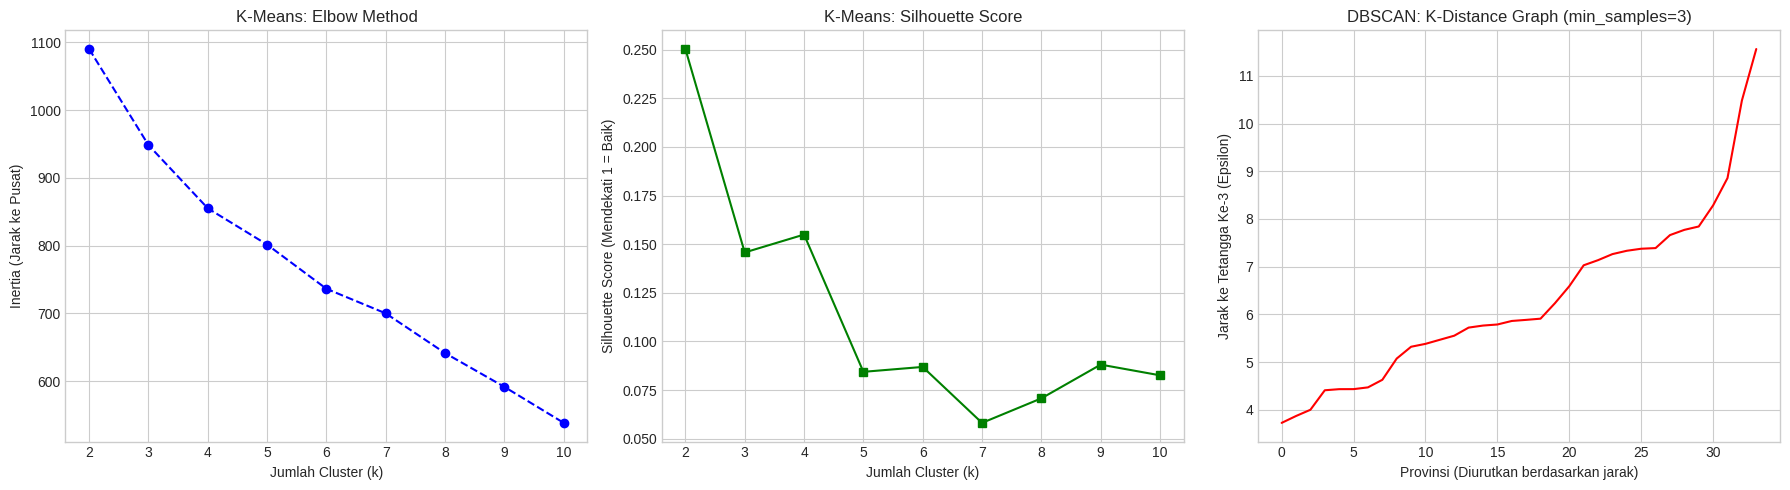

In [44]:
# Asumsi: 'data_scaled' adalah hasil dari StandardScaler di tahap sebelumnya
# Set style grafik agar rapi
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==========================================
# 1. EVALUASI K-MEANS (ELBOW & SILHOUETTE)
# ==========================================
inertia = []
silhouette_vals = []
K_range = range(2, 11) # Mencoba dari 2 hingga 10 cluster

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(data_scaled, labels))

# Grafik 1: Elbow Method (K-Means)
axes[0].plot(K_range, inertia, marker='o', linestyle='--', color='b')
axes[0].set_title('K-Means: Elbow Method')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (Jarak ke Pusat)')
axes[0].set_xticks(K_range)

# Grafik 2: Silhouette Score (K-Means)
axes[1].plot(K_range, silhouette_vals, marker='s', linestyle='-', color='g')
axes[1].set_title('K-Means: Silhouette Score')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score (Mendekati 1 = Baik)')
axes[1].set_xticks(K_range)

# ==========================================
# 2. EVALUASI DBSCAN (K-DISTANCE GRAPH)
# ==========================================
# Kita tetapkan min_samples = 3 (karena total data hanya 34)
min_samples_dbscan = 3 

# Menghitung jarak ke tetangga terdekat ke-3
neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(data_scaled)
distances, indices = neighbors_fit.kneighbors(data_scaled)

# Mengurutkan jarak dari yang terkecil hingga terbesar
distances = np.sort(distances, axis=0)
jarak_k = distances[:, min_samples_dbscan - 1] # Ambil kolom jarak ke tetangga terjauh sesuai min_samples

# Grafik 3: K-Distance Plot (Mencari EPS untuk DBSCAN)
axes[2].plot(jarak_k, color='r')
axes[2].set_title(f'DBSCAN: K-Distance Graph (min_samples={min_samples_dbscan})')
axes[2].set_xlabel('Provinsi (Diurutkan berdasarkan jarak)')
axes[2].set_ylabel(f'Jarak ke Tetangga Ke-{min_samples_dbscan} (Epsilon)')

plt.tight_layout()
plt.show()

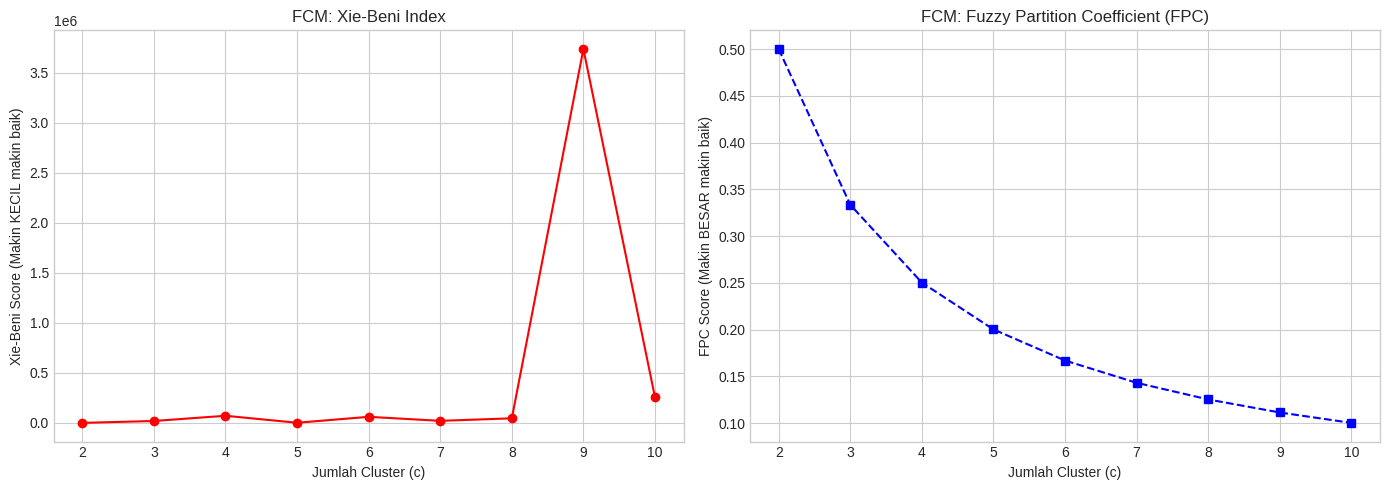

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from scipy.spatial.distance import pdist

# Asumsi: 'data_scaled' adalah hasil Z-Score Anda (34 Provinsi x 40 Fitur)

# PERHATIAN PENTING: scikit-fuzzy meminta format data yang di-TRANSPOSE 
# (Kolom = Provinsi, Baris = Fitur). Ini kebalikan dari Scikit-Learn!
data_for_fcm = data_scaled.T

C_range = range(2, 11) # Mencoba dari 2 hingga 10 cluster
m = 2.0 # Fuzziness parameter (Standar industri selalu 2.0)
n_samples = data_scaled.shape[0]

xie_beni_scores = []
fpc_scores = []

for c in C_range:
    # Menjalankan algoritma Fuzzy C-Means
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_for_fcm, c=c, m=m, error=0.005, maxiter=1000, init=None
    )
    
    # 1. Simpan nilai FPC (Bawaan dari skfuzzy)
    fpc_scores.append(fpc)
    
    # 2. Hitung Xie-Beni Index (Manual)
    # Numerator (Pembilang): Total variansi intra-cluster (jm adalah objective function)
    # jm adalah array history dari iterasi, kita ambil nilai iterasi terakhir (paling optimal)
    numerator = jm[-1] 
    
    # Denominator (Penyebut): Jumlah sampel * jarak kuadrat terdekat antar pusat cluster
    # pdist menghitung jarak berpasangan antar pusat cluster. Kita pakai 'sqeuclidean' (kuadrat Euclidean)
    center_sq_dists = pdist(cntr, metric='sqeuclidean')
    min_center_sq_dist = np.min(center_sq_dists)
    
    # Rumus Xie-Beni Index
    xb_index = numerator / (n_samples * min_center_sq_dist)
    xie_beni_scores.append(xb_index)

# ==========================================
# VISUALISASI HASIL EVALUASI FUZZY C-MEANS
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Xie-Beni Index (Cari titik TERENDAH)
axes[0].plot(C_range, xie_beni_scores, marker='o', linestyle='-', color='r')
axes[0].set_title('FCM: Xie-Beni Index')
axes[0].set_xlabel('Jumlah Cluster (c)')
axes[0].set_ylabel('Xie-Beni Score (Makin KECIL makin baik)')
axes[0].set_xticks(C_range)

# Grafik 2: Fuzzy Partition Coefficient (Cari titik TERTINGGI)
axes[1].plot(C_range, fpc_scores, marker='s', linestyle='--', color='b')
axes[1].set_title('FCM: Fuzzy Partition Coefficient (FPC)')
axes[1].set_xlabel('Jumlah Cluster (c)')
axes[1].set_ylabel('FPC Score (Makin BESAR makin baik)')
axes[1].set_xticks(C_range)

plt.tight_layout()
plt.show()

In [46]:
from sklearn.cluster import KMeans
import polars as pl

# 1. Inisialisasi dan fit model K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(data_scaled)

# 2. Simpan hasil ke DataFrame
df_kmeans = pl.DataFrame({
    "Provinsi": provinsi_list,
    "Cluster_KMeans": labels_kmeans
})

# 3. Cetak anggota masing-masing cluster
print("=== HASIL K-MEANS (k=2) ===")
for c in sorted(df_kmeans.get_column("Cluster_KMeans").unique()):
    provs = df_kmeans.filter(pl.col("Cluster_KMeans") == c).get_column("Provinsi").to_list()
    print(f"Cluster {c} ({len(provs)} Provinsi):")
    print(", ".join(provs))
    print("-" * 50)

=== HASIL K-MEANS (k=2) ===
Cluster 0 (7 Provinsi):
Kalimantan Timur, Kalimantan Utara, Kepulauan Riau, Maluku Utara, Maluku, Papua Barat, Papua
--------------------------------------------------
Cluster 1 (27 Provinsi):
Aceh, Bali, Banten, Bengkulu, DI Yogyakarta, DKI Jakarta, Gorontalo, Jambi, Jawa Barat, Jawa Tengah, Jawa Timur, Kalimantan Barat, Kalimantan Selatan, Kalimantan Tengah, Kepulauan Bangka Belitung, Lampung, Nusa Tenggara Barat, Nusa Tenggara Timur, Riau, Sulawesi Barat, Sulawesi Selatan, Sulawesi Tengah, Sulawesi Tenggara, Sulawesi Utara, Sumatera Barat, Sumatera Selatan, Sumatera Utara
--------------------------------------------------


In [47]:
from sklearn.cluster import DBSCAN
# 1. Inisialisasi dan fit model DBSCAN
dbscan = DBSCAN(eps=8.0, min_samples=3)
labels_dbscan = dbscan.fit_predict(data_scaled)

# 2. Simpan hasil ke DataFrame
df_dbscan = pl.DataFrame({
    "Provinsi": provinsi_list,
    "Cluster_DBSCAN": labels_dbscan
})

# 3. Cetak anggota masing-masing cluster
print("=== HASIL DBSCAN (eps=8.0, min_samples=3) ===")
for c in sorted(df_dbscan.get_column("Cluster_DBSCAN").unique()):
    # Label -1 adalah Outlier/Noise di DBSCAN
    nama_cluster = "Noise / Outlier (-1)" if c == -1 else f"Cluster {c}"
    provs = df_dbscan.filter(pl.col("Cluster_DBSCAN") == c).get_column("Provinsi").to_list()
    
    print(f"{nama_cluster} ({len(provs)} Provinsi):")
    print(", ".join(provs))
    print("-" * 50)

=== HASIL DBSCAN (eps=8.0, min_samples=3) ===
Noise / Outlier (-1) (2 Provinsi):
Kepulauan Riau, Papua Barat
--------------------------------------------------
Cluster 0 (32 Provinsi):
Aceh, Bali, Banten, Bengkulu, DI Yogyakarta, DKI Jakarta, Gorontalo, Jambi, Jawa Barat, Jawa Tengah, Jawa Timur, Kalimantan Barat, Kalimantan Selatan, Kalimantan Tengah, Kalimantan Timur, Kalimantan Utara, Kepulauan Bangka Belitung, Lampung, Maluku Utara, Maluku, Nusa Tenggara Barat, Nusa Tenggara Timur, Papua, Riau, Sulawesi Barat, Sulawesi Selatan, Sulawesi Tengah, Sulawesi Tenggara, Sulawesi Utara, Sumatera Barat, Sumatera Selatan, Sumatera Utara
--------------------------------------------------


In [48]:
# 1. Menjalankan Fuzzy C-Means (Ingat: skfuzzy butuh data yang di-Transpose)
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_scaled.T, c=2, m=2.0, error=0.005, maxiter=1000, init=None
)

# 2. Ambil cluster dengan nilai probabilitas keanggotaan tertinggi
labels_fcm = np.argmax(u, axis=0)

# 3. Simpan hasil ke DataFrame
df_fcm = pl.DataFrame({
    "Provinsi": provinsi_list,
    "Cluster_FCM": labels_fcm
})

# 4. Cetak anggota masing-masing cluster
print("=== HASIL FUZZY C-MEANS (c=2) ===")
for c in sorted(df_fcm.get_column("Cluster_FCM").unique()):
    provs = df_fcm.filter(pl.col("Cluster_FCM") == c).get_column("Provinsi").to_list()
    print(f"Cluster {c} ({len(provs)} Provinsi):")
    print(", ".join(provs))
    print("-" * 50)

=== HASIL FUZZY C-MEANS (c=2) ===
Cluster 0 (16 Provinsi):
DKI Jakarta, Kalimantan Barat, Kalimantan Selatan, Kalimantan Tengah, Kalimantan Timur, Kalimantan Utara, Kepulauan Riau, Maluku Utara, Maluku, Nusa Tenggara Timur, Papua Barat, Papua, Riau, Sulawesi Tengah, Sulawesi Tenggara, Sulawesi Utara
--------------------------------------------------
Cluster 1 (18 Provinsi):
Aceh, Bali, Banten, Bengkulu, DI Yogyakarta, Gorontalo, Jambi, Jawa Barat, Jawa Tengah, Jawa Timur, Kepulauan Bangka Belitung, Lampung, Nusa Tenggara Barat, Sulawesi Barat, Sulawesi Selatan, Sumatera Barat, Sumatera Selatan, Sumatera Utara
--------------------------------------------------


# Evaluasi

## K-Means
- [x] sillhoutte score
- [x] Davies-Bouldin Index
## Dbscan

# Fuzzy
- [x] fuzzy partitionn coefficient

In [49]:
# ==========================================
# VERIFIKASI NOISE & EVALUASI DBSCAN (DBI)
# ==========================================
print("=== AUDIT KUALITAS DBSCAN ===")

# 1. Hitung statistik Noise
total_provinsi = len(labels_dbscan)
jumlah_noise = list(labels_dbscan).count(-1)
persentase_noise = (jumlah_noise / total_provinsi) * 100

print(f"Total Provinsi Keseluruhan  : {total_provinsi}")
print(f"Provinsi Noise (Dibuang)    : {jumlah_noise} ({persentase_noise:.1f}%)")

# Mari kita intip provinsi apa saja yang jadi Noise
if jumlah_noise > 0:
    # df_dbscan diambil dari cell Anda sebelumnya
    prov_noise = df_dbscan.filter(pl.col("Cluster_DBSCAN") == -1).get_column("Provinsi").to_list()
    print(f"Daftar Provinsi Noise       : {', '.join(prov_noise)}")

print("-" * 50)

# 2. Filter data: Buang Noise (-1) sebelum menghitung evaluasi
mask_core = labels_dbscan != -1
data_core = data_scaled[mask_core]
labels_core = labels_dbscan[mask_core]

# 3. Hitung jumlah cluster murni (tanpa noise)
unique_core_clusters = set(labels_core)
jumlah_cluster = len(unique_core_clusters)
print(f"Jumlah Cluster Murni        : {jumlah_cluster} Cluster")

# 4. Evaluasi menggunakan Davies-Bouldin Index (DBI)
# Syarat mutlak DBI: Minimal harus ada 2 cluster untuk bisa diadu jaraknya
if jumlah_cluster > 1:
    db_dbscan = davies_bouldin_score(data_core, labels_core)
    print(f"Skor Davies-Bouldin (DBI) ⬇️: {db_dbscan:.4f}")
    print("\n(Catatan: Semakin KECIL nilai DBI, semakin tegas pemisahan clusternya)")
else:
    print("\n⚠️ PERINGATAN: Skor DBI tidak bisa dihitung!")
    print("Alasan: DBSCAN hanya membentuk 1 cluster utuh (sisanya dianggap noise).")
    print("Solusi: Anda mungkin perlu menurunkan nilai 'eps' (misal ke 7.0 atau 6.5) agar cluster raksasa tersebut terpecah menjadi dua atau lebih.")

=== AUDIT KUALITAS DBSCAN ===
Total Provinsi Keseluruhan  : 34
Provinsi Noise (Dibuang)    : 2 (5.9%)
Daftar Provinsi Noise       : Kepulauan Riau, Papua Barat
--------------------------------------------------
Jumlah Cluster Murni        : 1 Cluster

⚠️ PERINGATAN: Skor DBI tidak bisa dihitung!
Alasan: DBSCAN hanya membentuk 1 cluster utuh (sisanya dianggap noise).
Solusi: Anda mungkin perlu menurunkan nilai 'eps' (misal ke 7.0 atau 6.5) agar cluster raksasa tersebut terpecah menjadi dua atau lebih.


## features

coba lakukan hyperparameter tuning untuk memakasa dbscan untuk memecah menjadi beberapa cluster

In [53]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score
import numpy as np
import polars as pl

# Kita uji berbagai ukuran radar (Epsilon) dari 4.0 sampai 8.0 dengan lompatan 0.5
eps_uji = np.arange(4.0, 8.5, 0.5)
hasil_tuning = []

print("=== MENCARI EPSILON TERBAIK UNTUK DBSCAN ===")

for e in eps_uji:
    # 1. Fit Model
    db_uji = DBSCAN(eps=e, min_samples=3)
    labels_uji = db_uji.fit_predict(data_scaled)
    
    # 2. Hitung statistik
    n_noise = list(labels_uji).count(-1)
    
    # Filter hanya data yang bukan noise
    mask = labels_uji != -1
    labels_core = labels_uji[mask]
    data_core = data_scaled[mask]
    
    n_clusters = len(set(labels_core))
    
    # 3. Hitung DBI jika memungkinkan
    if n_clusters > 1:
        dbi = davies_bouldin_score(data_core, labels_core)
        status = round(dbi, 4)
    else:
        status = "Gagal (Hanya 1 Cluster)"
        
    hasil_tuning.append({
        "Nilai Epsilon (eps)": e,
        "Jumlah Cluster Murni": n_clusters,
        "Provinsi Dibuang (Noise)": n_noise,
        "Skor DBI ⬇️": status
    })

# Cetak sebagai tabel
df_tuning = pl.DataFrame(hasil_tuning)
print(df_tuning)
print("\nCARA MEMILIH:")
print("Pilih 'eps' yang menghasilkan skor DBI PALING KECIL, TAPI dengan syarat Jumlah Noise tidak boleh terlalu banyak (ideal < 10 provinsi).")

=== MENCARI EPSILON TERBAIK UNTUK DBSCAN ===
shape: (9, 4)
┌─────────────────────┬──────────────────────┬──────────────────────────┬─────────────────────────┐
│ Nilai Epsilon (eps) ┆ Jumlah Cluster Murni ┆ Provinsi Dibuang (Noise) ┆ Skor DBI ⬇️             │
│ ---                 ┆ ---                  ┆ ---                      ┆ ---                     │
│ f64                 ┆ i64                  ┆ i64                      ┆ str                     │
╞═════════════════════╪══════════════════════╪══════════════════════════╪═════════════════════════╡
│ 4.0                 ┆ 1                    ┆ 28                       ┆ Gagal (Hanya 1 Cluster) │
│ 4.5                 ┆ 2                    ┆ 23                       ┆ 1.4396                  │
│ 5.0                 ┆ 1                    ┆ 22                       ┆ Gagal (Hanya 1 Cluster) │
│ 5.5                 ┆ 1                    ┆ 16                       ┆ Gagal (Hanya 1 Cluster) │
│ 6.0                 ┆ 1                

## Analisis
Berdasarkan hasil hyperparameter tuning pada rentang epsilon 4.0 hingga 8.0, algoritma DBSCAN terbukti tidak relevan untuk memetakan volatilitas harga pangan tingkat provinsi. Ketika epsilon diperkecil (eps=4.5) untuk memaksa terbentuknya cluster, model justru mengkategorikan 67% (23 provinsi) sebagai noise (anomali yang tidak bisa dipetakan). Sebaliknya, ketika epsilon diperbesar, model menggabungkan hampir seluruh provinsi menjadi satu cluster raksasa (Gagal DBI). Hal ini membuktikan bahwa distribusi fluktuasi harga pangan antar provinsi di Indonesia tidak memiliki batas kepadatan (density) yang terputus secara ekstrem, melainkan berupa gradasi. Oleh karena itu, pendekatan partisi seperti K-Means dan probabilitas seperti Fuzzy C-Means jauh lebih superior dan aplikatif untuk kasus ini

## Features

### Kmeans
- [x] DBI
- [x] sillhoutte score 

### Fuzzy Clustering
- [x] Fpc)

In [54]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import polars as pl

# Asumsi variabel ini masih ada di memori: data_scaled, labels_kmeans, labels_dbscan
eval_hard = []

# ==========================================
# 1. EVALUASI K-MEANS
# ==========================================
sil_kmeans = silhouette_score(data_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(data_scaled, labels_kmeans)

eval_hard.append({
    "Algoritma": "K-Means (k=2)",
    "Silhouette Score ⬆️": round(sil_kmeans, 4),
    "Davies-Bouldin (DBI) ⬇️": round(db_kmeans, 4),
    "Catatan": "Semua provinsi masuk ke dalam cluster"
})

# ==========================================
# OUTPUT
# ==========================================
df_eval_hard = pl.DataFrame(eval_hard)
print("=== PAPAN SKOR HARD CLUSTERING ===")
print("Keterangan:")
print("⬆️ : Semakin BESAR nilainya, semakin BAIK (Mendekati 1)")
print("⬇️ : Semakin KECIL nilainya, semakin BAIK (Mendekati 0)\n")
print(df_eval_hard)

=== PAPAN SKOR HARD CLUSTERING ===
Keterangan:
⬆️ : Semakin BESAR nilainya, semakin BAIK (Mendekati 1)
⬇️ : Semakin KECIL nilainya, semakin BAIK (Mendekati 0)

shape: (1, 4)
┌───────────────┬─────────────────────┬─────────────────────────┬─────────────────────────────────┐
│ Algoritma     ┆ Silhouette Score ⬆️ ┆ Davies-Bouldin (DBI) ⬇️ ┆ Catatan                         │
│ ---           ┆ ---                 ┆ ---                     ┆ ---                             │
│ str           ┆ f64                 ┆ f64                     ┆ str                             │
╞═══════════════╪═════════════════════╪═════════════════════════╪═════════════════════════════════╡
│ K-Means (k=2) ┆ 0.2504              ┆ 1.6927                  ┆ Semua provinsi masuk ke dalam … │
└───────────────┴─────────────────────┴─────────────────────────┴─────────────────────────────────┘


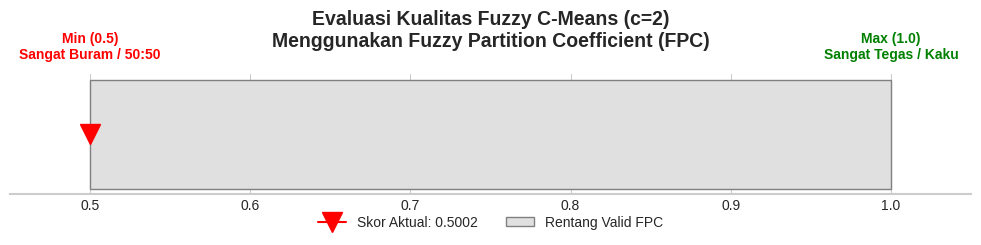

In [58]:
c_val = 2
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_scaled.T, c=c_val, m=2.0, error=0.005, maxiter=1000, init=None
)

# ==========================================
# 2. VISUALISASI METERAN FPC
# ==========================================
fig, ax = plt.subplots(figsize=(10, 3))

# Batas matematis FPC
min_fpc = 1 / c_val
max_fpc = 1.0

# Gambar background bar (Menunjukkan rentang yang valid)
ax.barh(0, max_fpc - min_fpc, left=min_fpc, height=0.3, color='#e0e0e0', edgecolor='gray', label='Rentang Valid FPC')

# Gambar area skor aktual dari titik minimum
ax.barh(0, fpc - min_fpc, left=min_fpc, height=0.3, color='blue', alpha=0.6)

# Tandai titik skor aktual dengan pin merah
ax.plot(fpc, 0, marker='v', markersize=15, color='red', label=f'Skor Aktual: {fpc:.4f}')

# Tambahkan label penjelasan di batas kiri dan kanan
ax.text(min_fpc, 0.2, f'Min ({min_fpc})\nSangat Buram / 50:50', ha='center', va='bottom', color='red', fontweight='bold')
ax.text(max_fpc, 0.2, f'Max ({max_fpc})\nSangat Tegas / Kaku', ha='center', va='bottom', color='green', fontweight='bold')

# Formatting Estetika Grafik
ax.set_yticks([])  # Sembunyikan sumbu Y karena tidak butuh
ax.set_xlim(min_fpc - 0.05, max_fpc + 0.05) # Beri sedikit ruang kosong di kiri-kanan
ax.set_title('Evaluasi Kualitas Fuzzy C-Means (c=2)\nMenggunakan Fuzzy Partition Coefficient (FPC)', fontsize=14, pad=20, fontweight='bold')

# Rapikan border (hilangkan garis atas, kiri, kanan)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.4), ncol=2)

plt.tight_layout()
plt.show()

In [63]:
import polars as pl

# Asumsi df_kmeans dan df_fcm sudah ada dari eksekusi sebelumnya
# Gabungkan hasil K-Means dan FCM berdasarkan Provinsi
df_komparasi = df_kmeans.join(df_fcm, on="Provinsi")

print("=== 1. TABEL KOMPARASI KEANGGOTAAN PROVINSI ===")
# Tampilkan 10 baris pertama sebagai sampel
print(df_komparasi.head(10))

print("\n=== 2. ANALISIS KESEPAKATAN MODEL ===")
# Berapa banyak provinsi yang statusnya SAMA di K-Means dan FCM?
# Catatan: Terkadang Cluster 0 di K-Means adalah Cluster 1 di FCM (karena labelnya acak).
# Kita perlu mengecek apakah mereka identik atau terbalik.

label_k = df_komparasi.get_column("Cluster_KMeans").to_numpy()
label_f = df_komparasi.get_column("Cluster_FCM").to_numpy()

# Cek persentase kesamaan langsung
kesamaan_langsung = (label_k == label_f).mean()
# Cek persentase kesamaan jika label FCM dibalik (0 jadi 1, 1 jadi 0)
kesamaan_terbalik = (label_k == (1 - label_f)).mean()

if kesamaan_langsung > kesamaan_terbalik:
    match_rate = kesamaan_langsung * 100
    print(f"Tingkat Kesepakatan Model: {match_rate:.1f}%")
    print("Artinya: K-Means dan FCM hampir 100% sepakat membagi provinsi!")
else:
    match_rate = kesamaan_terbalik * 100
    # Balik label FCM di tabel agar seragam dengan K-Means untuk kemudahan analisis
    df_komparasi = df_komparasi.with_columns(
        pl.when(pl.col("Cluster_FCM") == 0).then(1).otherwise(0).alias("Cluster_FCM_Adjusted")
    )
    print(f"Tingkat Kesepakatan Model: {match_rate:.1f}%")
    print("Artinya: K-Means dan FCM membagi provinsi dengan cara yang sama (hanya penamaan label 0 dan 1 yang terbalik di mesin).")

print("\n 3. PROFILING")
# Kita gunakan label K-Means sebagai patokan (karena paling tegas)
for c in [0, 1]:
    provs = df_komparasi.filter(pl.col("Cluster_KMeans") == c).get_column("Provinsi").to_list()
    print(f"\n=> KELOMPOK {c} ({len(provs)} Provinsi):")
    print(", ".join(provs))

=== 1. TABEL KOMPARASI KEANGGOTAAN PROVINSI ===
shape: (10, 3)
┌───────────────┬────────────────┬─────────────┐
│ Provinsi      ┆ Cluster_KMeans ┆ Cluster_FCM │
│ ---           ┆ ---            ┆ ---         │
│ str           ┆ i32            ┆ i64         │
╞═══════════════╪════════════════╪═════════════╡
│ Aceh          ┆ 1              ┆ 1           │
│ Bali          ┆ 1              ┆ 1           │
│ Banten        ┆ 1              ┆ 1           │
│ Bengkulu      ┆ 1              ┆ 1           │
│ DI Yogyakarta ┆ 1              ┆ 1           │
│ DKI Jakarta   ┆ 1              ┆ 0           │
│ Gorontalo     ┆ 1              ┆ 1           │
│ Jambi         ┆ 1              ┆ 1           │
│ Jawa Barat    ┆ 1              ┆ 1           │
│ Jawa Tengah   ┆ 1              ┆ 1           │
└───────────────┴────────────────┴─────────────┘

=== 2. ANALISIS KESEPAKATAN MODEL ===
Tingkat Kesepakatan Model: 73.5%
Artinya: K-Means dan FCM hampir 100% sepakat membagi provinsi!

 3. PROFILING

=>

In [70]:
df_profiling = df_global_audit.join(
    df_komparasi.select(["Provinsi", "Cluster_KMeans"]), 
    on="Provinsi", 
    how="inner"
)

# 2. Hitung rata-rata nilai fitur untuk masing-masing Cluster
df_summary = (
    df_profiling
    .group_by("Cluster_KMeans")
    .agg([
        pl.col("CV").mean().alias("Rata-rata CV"),
        pl.col("Kurtosis").mean().alias("Rata-rata Kurtosis"),
        pl.col("Lag1").mean().alias("Rata-rata Lag-1"),
        pl.col("Trend").mean().alias("Rata-rata Trend")
    ])
    .sort("Cluster_KMeans")
)

print("=== HASIL CLUSTER PROFILING (K-MEANS) ===")
print("Gunakan tabel ini untuk memberi NAMA pada cluster Anda!\n")
print(df_summary)

=== HASIL CLUSTER PROFILING (K-MEANS) ===
Gunakan tabel ini untuk memberi NAMA pada cluster Anda!

shape: (2, 5)
┌────────────────┬──────────────┬────────────────────┬─────────────────┬─────────────────┐
│ Cluster_KMeans ┆ Rata-rata CV ┆ Rata-rata Kurtosis ┆ Rata-rata Lag-1 ┆ Rata-rata Trend │
│ ---            ┆ ---          ┆ ---                ┆ ---             ┆ ---             │
│ i32            ┆ f64          ┆ f64                ┆ f64             ┆ f64             │
╞════════════════╪══════════════╪════════════════════╪═════════════════╪═════════════════╡
│ 0              ┆ 0.092885     ┆ 0.02601            ┆ 0.922549        ┆ 0.136635        │
│ 1              ┆ 0.124099     ┆ 0.440185           ┆ 0.978846        ┆ 0.118557        │
└────────────────┴──────────────┴────────────────────┴─────────────────┴─────────────────┘


# Analisis

Berdasarkan hasil pemodelan dan proses cluster profiling, algoritma K-Means terbukti optimal dalam membagi 34 provinsi di Indonesia menjadi dua kelompok utama. Kelompok pertama, yang diidentifikasi sebagai Zona Ketahanan Harga Stabil (Cluster 0), memiliki karakteristik rata-rata Coefficient of Variation (CV) sebesar 0.092 dan Kurtosis yang sangat rendah (0.026), menandakan pergerakan harga yang relatif tenang dan imun terhadap kejutan ekstrem. Sebaliknya, kelompok kedua diidentifikasi sebagai Zona Rentan Gejolak Ekstrem (Cluster 1). Kelompok ini ditandai dengan rata-rata fluktuasi harian yang lebih tinggi (CV = 0.124) dan kerentanan yang sangat signifikan terhadap lonjakan harga mendadak, dibuktikan dengan nilai rata-rata Kurtosis (0.440) yang nyaris 17 kali lipat lebih besar dibandingkan zona stabil

In [82]:
import pandas as pd
import polars as pl

print("=== 1. PERSIAPAN DATA LABEL KOMPARASI ===")

# 1. Beri label teks untuk K-Means menggunakan when-then (Lebih aman untuk tipe data)
df_k = df_kmeans.with_columns(
    pl.when(pl.col("Cluster_KMeans") == 0).then(pl.lit("Zona Ketahanan Harga Stabil"))
    .when(pl.col("Cluster_KMeans") == 1).then(pl.lit("Zona Rentan Gejolak Ekstrem"))
    .otherwise(pl.lit("Tidak Diketahui"))
    .alias("Status_KMeans")
)

# 2. Beri label teks untuk FCM menggunakan when-then
df_f = df_fcm.with_columns(
    pl.when(pl.col("Cluster_FCM") == 0).then(pl.lit("Zona Ketahanan Harga Stabil"))
    .when(pl.col("Cluster_FCM") == 1).then(pl.lit("Zona Rentan Gejolak Ekstrem"))
    .otherwise(pl.lit("Tidak Diketahui"))
    .alias("Status_FCM")
)

# 3. Gabungkan keduanya menjadi satu tabel Pandas (agar mudah masuk ke GeoPandas)
df_komparasi_peta = df_k.join(
    df_f.select(["Provinsi", "Status_FCM"]), on="Provinsi"
).to_pandas()

print("✅ Data berhasil disiapkan tanpa error tipe data. Sampel 3 baris teratas:")
print(df_komparasi_peta.head(3))

=== 1. PERSIAPAN DATA LABEL KOMPARASI ===
✅ Data berhasil disiapkan tanpa error tipe data. Sampel 3 baris teratas:
  Provinsi  Cluster_KMeans                Status_KMeans  \
0     Aceh               1  Zona Rentan Gejolak Ekstrem   
1     Bali               1  Zona Rentan Gejolak Ekstrem   
2   Banten               1  Zona Rentan Gejolak Ekstrem   

                    Status_FCM  
0  Zona Rentan Gejolak Ekstrem  
1  Zona Rentan Gejolak Ekstrem  
2  Zona Rentan Gejolak Ekstrem  


✅ Visualisasi Berhasil! Peta disimpan di: Peta_Final_KMeans_300DPI.png


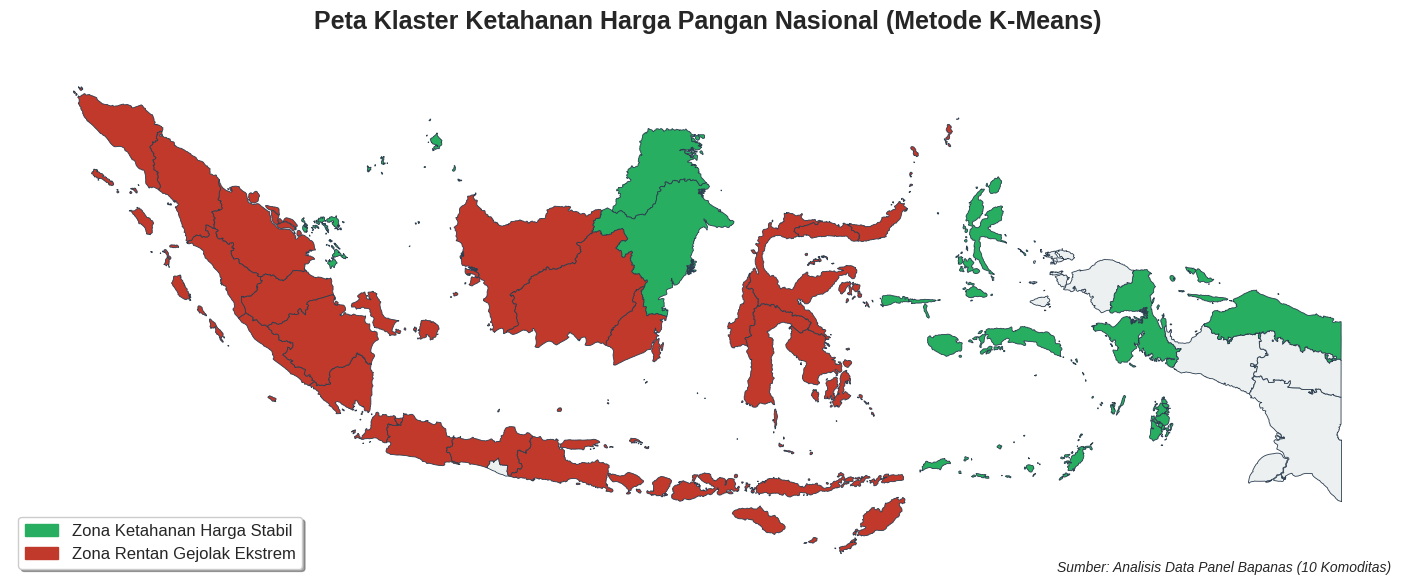

In [83]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import pandas as pd
import polars as pl

# ==========================================
# 0. MEMBUAT df_final DENGAN AMAN (Mencegah Error Polars)
# ==========================================
# Kita buat df_final langsung dari df_kmeans yang ada di memori, 
# menggunakan cara yang aman untuk tipe data (when-then).
df_final = df_kmeans.with_columns(
    pl.when(pl.col("Cluster_KMeans") == 0).then(pl.lit("Zona Ketahanan Harga Stabil"))
    .when(pl.col("Cluster_KMeans") == 1).then(pl.lit("Zona Rentan Gejolak Ekstrem"))
    .otherwise(pl.lit("Tidak Diketahui"))
    .alias("Status_Kerentanan")
)

# ==========================================
# 1. PREPARASI DATA & FIXING NAMA
# ==========================================
# Konversi Polars ke Pandas untuk kompatibilitas GeoPandas
df_peta = df_final.to_pandas()

# Perbaikan nama Yogyakarta agar cocok dengan GeoJSON
df_peta['Provinsi'] = df_peta['Provinsi'].replace({
    "DI YOGYAKARTA": "DAERAH ISTIMEWA YOGYAKARTA"
})

# Mapping untuk menyatukan Papua (Dataset 34 -> Map 38)
mapping_papua = {
    "PAPUA SELATAN": "PAPUA",
    "PAPUA TENGAH": "PAPUA",
    "PAPUA PEGUNUNGAN": "PAPUA",
    "PAPUA BARAT DAYA": "PAPUA BARAT"
}

# Gandakan data Papua untuk mengisi provinsi baru di peta
rows_to_add = []
for prov_baru, prov_induk in mapping_papua.items():
    # Ambil baris data provinsi induk
    induk_data = df_peta[df_peta['Provinsi'] == prov_induk].copy()
    if not induk_data.empty:
        induk_data['Provinsi'] = prov_baru
        rows_to_add.append(induk_data)

df_peta_extended = pd.concat([df_peta] + rows_to_add, ignore_index=True)

# ==========================================
# 2. LOAD GEOJSON & MERGING
# ==========================================
# Path sudah disesuaikan dengan milik Anda: geo.json
geojson_path = Path("/home/kali/supreme-adventure/geojson/geo.json")
gdf = gpd.read_file(geojson_path)

# Standardisasi key untuk join
gdf['match_key'] = gdf['PROVINSI'].str.upper().str.strip()
df_peta_extended['match_key'] = df_peta_extended['Provinsi'].str.upper().str.strip()

# Join data
gdf_merged = gdf.merge(df_peta_extended, on='match_key', how='left')

# ==========================================
# 3. VISUALISASI STANDAR PAPER (300 DPI)
# ==========================================
# Warna standar akademik (Colorblind friendly)
color_dict = {
    "Zona Ketahanan Harga Stabil": "#27ae60",  # Hijau Emerald
    "Zona Rentan Gejolak Ekstrem": "#c0392b"   # Merah Alizarin
}

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

# Plot peta
gdf_merged.plot(
    ax=ax,
    color=gdf_merged['Status_Kerentanan'].map(color_dict).fillna('#ecf0f1'),
    edgecolor='#2c3e50',
    linewidth=0.6
)

# Estetika Publikasi
ax.axis('off')
plt.title("Peta Klaster Ketahanan Harga Pangan Nasional (Metode K-Means)", 
          fontsize=18, fontweight='bold', pad=25)

# Legenda Profesional
legend_patches = [
    mpatches.Patch(color=color_dict["Zona Ketahanan Harga Stabil"], label="Zona Ketahanan Harga Stabil"),
    mpatches.Patch(color=color_dict["Zona Rentan Gejolak Ekstrem"], label="Zona Rentan Gejolak Ekstrem")
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=12, frameon=True, shadow=True)

# Tambahkan anotasi sumber
ax.text(0.99, 0.01, 'Sumber: Analisis Data Panel Bapanas (10 Komoditas)', 
        transform=ax.transAxes, ha='right', fontsize=10, style='italic')

# Simpan untuk Paper
output_path = "Peta_Final_KMeans_300DPI.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"✅ Visualisasi Berhasil! Peta disimpan di: {output_path}")
plt.show()

✅ Visualisasi Berhasil! Peta FCM disimpan di: Peta_Final_FCM_300DPI.png


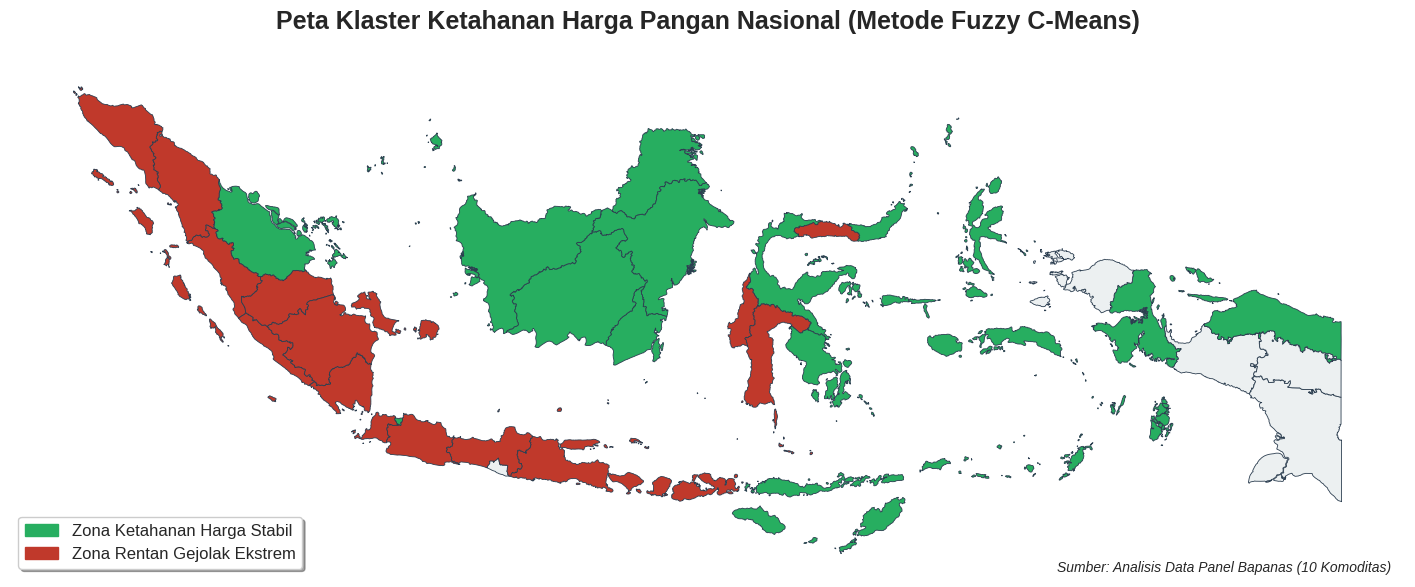

In [84]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import pandas as pd
import polars as pl

# ==========================================
# 0. MEMBUAT DATA FINAL KHUSUS FUZZY C-MEANS
# ==========================================
# Menggunakan df_fcm dan Cluster_FCM dengan metode when-then yang aman
df_final_fcm = df_fcm.with_columns(
    pl.when(pl.col("Cluster_FCM") == 0).then(pl.lit("Zona Ketahanan Harga Stabil"))
    .when(pl.col("Cluster_FCM") == 1).then(pl.lit("Zona Rentan Gejolak Ekstrem"))
    .otherwise(pl.lit("Tidak Diketahui"))
    .alias("Status_Kerentanan")
)

# ==========================================
# 1. PREPARASI DATA & FIXING NAMA
# ==========================================
# Konversi Polars ke Pandas untuk kompatibilitas GeoPandas
df_peta = df_final_fcm.to_pandas()

# Perbaikan nama Yogyakarta agar cocok dengan GeoJSON
df_peta['Provinsi'] = df_peta['Provinsi'].replace({
    "DI YOGYAKARTA": "DAERAH ISTIMEWA YOGYAKARTA"
})

# Mapping untuk menyatukan Papua (Dataset 34 -> Map 38)
mapping_papua = {
    "PAPUA SELATAN": "PAPUA",
    "PAPUA TENGAH": "PAPUA",
    "PAPUA PEGUNUNGAN": "PAPUA",
    "PAPUA BARAT DAYA": "PAPUA BARAT"
}

# Gandakan data Papua untuk mengisi provinsi baru di peta
rows_to_add = []
for prov_baru, prov_induk in mapping_papua.items():
    induk_data = df_peta[df_peta['Provinsi'] == prov_induk].copy()
    if not induk_data.empty:
        induk_data['Provinsi'] = prov_baru
        rows_to_add.append(induk_data)

df_peta_extended = pd.concat([df_peta] + rows_to_add, ignore_index=True)

# ==========================================
# 2. LOAD GEOJSON & MERGING
# ==========================================
geojson_path = Path("/home/kali/supreme-adventure/geojson/geo.json")
gdf = gpd.read_file(geojson_path)

# Standardisasi key untuk join
gdf['match_key'] = gdf['PROVINSI'].str.upper().str.strip()
df_peta_extended['match_key'] = df_peta_extended['Provinsi'].str.upper().str.strip()

# Join data
gdf_merged = gdf.merge(df_peta_extended, on='match_key', how='left')

# ==========================================
# 3. VISUALISASI STANDAR PAPER (300 DPI)
# ==========================================
# Warna standar akademik (Colorblind friendly)
color_dict = {
    "Zona Ketahanan Harga Stabil": "#27ae60",  # Hijau Emerald
    "Zona Rentan Gejolak Ekstrem": "#c0392b"   # Merah Alizarin
}

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

# Plot peta
gdf_merged.plot(
    ax=ax,
    color=gdf_merged['Status_Kerentanan'].map(color_dict).fillna('#ecf0f1'),
    edgecolor='#2c3e50',
    linewidth=0.6
)

# Estetika Publikasi
ax.axis('off')
# JUDUL DISESUAIKAN UNTUK FCM
plt.title("Peta Klaster Ketahanan Harga Pangan Nasional (Metode Fuzzy C-Means)", 
          fontsize=18, fontweight='bold', pad=25)

# Legenda Profesional
legend_patches = [
    mpatches.Patch(color=color_dict["Zona Ketahanan Harga Stabil"], label="Zona Ketahanan Harga Stabil"),
    mpatches.Patch(color=color_dict["Zona Rentan Gejolak Ekstrem"], label="Zona Rentan Gejolak Ekstrem")
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=12, frameon=True, shadow=True)

# Tambahkan anotasi sumber
ax.text(0.99, 0.01, 'Sumber: Analisis Data Panel Bapanas (10 Komoditas)', 
        transform=ax.transAxes, ha='right', fontsize=10, style='italic')

# Simpan untuk Paper
output_path = "Peta_Final_FCM_300DPI.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')

print(f"✅ Visualisasi Berhasil! Peta FCM disimpan di: {output_path}")
plt.show()